<a href="https://colab.research.google.com/github/sanmquin/AI/blob/main/research/3.Shape-vs-Description.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Point-Cloud Shape vs Description Structure

This notebook compares the **geometric shape** of each channel's video point cloud with the
**semantic structure** of its LLM-generated description.

The description is first split into semantically meaningful segments using Gemini (with
skip-if-exists caching).  Three structural hypotheses are then tested:

| Hypothesis | Point-cloud property | Description property |
|---|---|---|
| H1 | Large volume (spread-out cloud) | Broad, diverse description (many segments, high semantic span) |
| H2 | Overlapping clouds between channels | Overlapping or similar description segments between channels |
| H3 | Concentrated cloud (tight cluster) | Focused description (low semantic diversity of segments) |

Results are presented as scatter plots, a correlation matrix, and summary statistics.


## 1) Setup

Install dependencies, mount Drive, and initialise the environment.


In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn scipy sentence-transformers

import json
import time
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull
from scipy.spatial.distance import cdist, squareform
from scipy.stats import pearsonr
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

try:
    from google.colab import ai, drive
    drive.mount('/content/drive')
    is_colab = True
except ImportError:
    print('Not running in Colab — headless mode.')
    is_colab = False


Mounted at /content/drive


## 2) Load data

Load the 20D video embeddings and the combined channel descriptions artifact produced by
`1.Channel-Descriptions.ipynb`.


In [2]:
DATA_PATH = Path(
    '/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/'
    'business_cluster_video_embeddings_reduced_20d.csv'
)
DESC_PATH = Path('/content/drive/MyDrive/Research/channel_descriptions/latest/all_channels.json')

RESEARCH_ROOT = Path('/content/drive/MyDrive/Research') if is_colab else Path('./research_output')

if not DATA_PATH.exists():
    print('Warning: embedding CSV not found — using dummy data.')
    rng = np.random.default_rng(1)
    channel_names = [f'Channel_{c}' for c in ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon']]
    rows = []
    for i in range(200):
        ch = channel_names[i % len(channel_names)]
        rows.append({
            'video_id': f'vid_{i}', 'channel_id': f'ch_{i%5}', 'channel_name': ch,
            'video_title': f'Video {i}', 'view_count': int(rng.integers(1000, 100000)),
            **{f'embedding_reduced_{j+1:02d}': float(rng.standard_normal()) for j in range(20)},
        })
    df = pd.DataFrame(rows)
else:
    df = pd.read_csv(DATA_PATH)

channel_col = 'channel_name' if 'channel_name' in df.columns else 'channel_id'
dim_cols    = sorted([c for c in df.columns if c.startswith('embedding_reduced_')])
channels    = df[channel_col].dropna().unique().tolist()

if not DESC_PATH.exists():
    print('Warning: descriptions file not found — using dummy descriptions.')
    descriptions = {
        ch: {'description': (
            f'The {ch} channel covers a wide range of topics from technology to entrepreneurship. '
            f'It features interviews with founders and investors. The content targets ambitious '
            f'professionals seeking actionable insights. A strong focus on AI and startups is evident.'
        )}
        for ch in channels
    }
else:
    with open(DESC_PATH) as fh:
        all_desc = json.load(fh)
    descriptions = {ch: data for ch, data in all_desc.get('channels', {}).items()
                    if ch in channels}

channels = [ch for ch in channels if ch in descriptions]
print(f'Loaded {len(df):,} videos, {len(channels)} aligned channels.')


Loaded 1,344 videos, 27 aligned channels.


## 3) Semantic chunking with Gemini

Each channel description is split into semantically meaningful segments using Gemini.  The
model is asked to return a JSON array of segment strings that together cover the full
description without overlap.

Chunks are saved per channel to `Research/channel_chunks/by_channel/{slug}_chunks.json`.
If a channel's chunk file already exists on Drive it is loaded directly, avoiding redundant
API calls.  The overall `all_chunks.json` is written after all channels are processed.

Splitting granularity is set to **3–7 segments** per description to balance coverage and
comparability.


In [3]:
def call_gemini(prompt: str) -> str:
    """Call Gemini via the Colab native integration; return placeholder in headless mode."""
    if is_colab:
        try:
            time.sleep(2)
            return ai.generate_text(prompt)
        except Exception as exc:
            print(f'  Gemini error: {exc}')
            return '[]'
    return '[]'


def parse_json_response(raw: str) -> list:
    """Extract a JSON array from raw Gemini output, handling markdown code fences."""
    text = raw.strip()
    # Strip markdown fences if present
    text = re.sub(r'^```(?:json)?\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    try:
        result = json.loads(text)
        if isinstance(result, list):
            return result
    except json.JSONDecodeError:
        pass
    return []


CHUNKS_BY_CH = RESEARCH_ROOT / 'channel_chunks' / 'by_channel'
CHUNKS_BY_CH.mkdir(parents=True, exist_ok=True)

all_chunks: dict = {}

for channel_name in channels:
    slug          = channel_name.replace('/', '_').replace(' ', '_').replace('\\', '_')
    chunk_path    = CHUNKS_BY_CH / f'{slug}_chunks.json'

    # Skip if already done
    if chunk_path.exists():
        print(f'  [SKIP] {channel_name}')
        with open(chunk_path) as fh:
            all_chunks[channel_name] = json.load(fh)
        continue

    print(f'  [CHUNK] {channel_name}')
    description = descriptions[channel_name]['description']

    prompt = f"""You are a text segmentation expert.

Below is a description of the YouTube channel "{channel_name}".
Split the description into 3 to 7 semantically meaningful segments.
Each segment should be a self-contained statement about the channel.
Do not paraphrase or add new information — only redistribute the existing text.

Return ONLY a valid JSON array of strings, one string per segment.
Example format: ["Segment one text.", "Segment two text.", "Segment three text."]

Description:
{description}
"""

    raw      = call_gemini(prompt)
    segments = parse_json_response(raw)

    # Fallback: if Gemini returned nothing useful, split on sentence boundaries
    if not segments:
        sentences = re.split(r'(?<=[.!?])\s+', description.strip())
        # Merge into roughly 4 groups
        k = max(1, len(sentences) // 4)
        segments = [' '.join(sentences[i:i+k]) for i in range(0, len(sentences), k)]

    artifact = {
        'channel_name': channel_name,
        'segment_count': len(segments),
        'segments': segments,
        'generated_at': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    }

    with open(chunk_path, 'w') as fh:
        json.dump(artifact, fh, indent=2)

    all_chunks[channel_name] = artifact
    print(f'       {len(segments)} segments → {chunk_path}')

# Save combined artifact
chunks_dir = RESEARCH_ROOT / 'channel_chunks' / 'latest'
chunks_dir.mkdir(parents=True, exist_ok=True)
with open(chunks_dir / 'all_chunks.json', 'w') as fh:
    json.dump({'schema_version': '1.0.0', 'channels': all_chunks}, fh, indent=2)
print(f'\nAll chunks saved to {chunks_dir / "all_chunks.json"}')


  [CHUNK] Bg2 Pod
       6 segments → /content/drive/MyDrive/Research/channel_chunks/by_channel/Bg2_Pod_chunks.json
  [CHUNK] The Prof G Pod – Scott Galloway
       5 segments → /content/drive/MyDrive/Research/channel_chunks/by_channel/The_Prof_G_Pod_–_Scott_Galloway_chunks.json
  [CHUNK] Asianometry
       7 segments → /content/drive/MyDrive/Research/channel_chunks/by_channel/Asianometry_chunks.json
  [CHUNK] Lenny's Podcast
       7 segments → /content/drive/MyDrive/Research/channel_chunks/by_channel/Lenny's_Podcast_chunks.json
  [CHUNK] a16z
       6 segments → /content/drive/MyDrive/Research/channel_chunks/by_channel/a16z_chunks.json
  [CHUNK] Dan Martell
       3 segments → /content/drive/MyDrive/Research/channel_chunks/by_channel/Dan_Martell_chunks.json
  [CHUNK] Patrick Boyle
       7 segments → /content/drive/MyDrive/Research/channel_chunks/by_channel/Patrick_Boyle_chunks.json
  [CHUNK] Real Vision Presents
       7 segments → /content/drive/MyDrive/Research/channel_chunks/by_c

## 4) Point-cloud shape metrics

Three geometric properties of each channel's point cloud are measured:

- **Volume** (`pc_volume`): total variance explained by a PCA decomposition of the channel's
  20D embeddings.  High variance means the channel covers a broad semantic range.
- **Concentration** (`pc_concentration`): mean Euclidean distance of each video from the
  channel centroid.  A high value means the cloud is spread out; a low value means it is
  tightly packed around one topic.
- **Inter-channel overlap** (`pc_overlap`): for a given channel, the mean minimum distance
  from its videos to every *other* channel's videos, averaged across all other channels.
  Small overlap means the channel occupies a distinct region of the embedding space.


In [4]:
clouds    = {ch: df[df[channel_col] == ch][dim_cols].dropna().values for ch in channels}
centroids = {ch: clouds[ch].mean(axis=0) for ch in channels}

def pc_volume(A: np.ndarray) -> float:
    """Sum of eigenvalues from PCA — total variance; proxy for point-cloud volume."""
    if len(A) < 2:
        return 0.0
    pca = PCA()
    pca.fit(A)
    return float(pca.explained_variance_.sum())

def pc_concentration(A: np.ndarray) -> float:
    """Mean distance of each point to the cloud centroid."""
    centroid = A.mean(axis=0)
    return float(np.linalg.norm(A - centroid, axis=1).mean())

def pc_inter_overlap(channel_name: str) -> float:
    """
    Mean of the mean-minimum distances from this channel to each other channel.
    Smaller = more overlap with other channels.
    """
    A = clouds[channel_name]
    dists = []
    for other_ch in channels:
        if other_ch == channel_name:
            continue
        B    = clouds[other_ch]
        d_ab = cdist(A, B, metric='euclidean')
        dists.append(d_ab.min(axis=1).mean())
    return float(np.mean(dists)) if dists else 0.0

shape_rows = []
for ch in channels:
    shape_rows.append({
        'channel_name':    ch,
        'pc_volume':       pc_volume(clouds[ch]),
        'pc_concentration':pc_concentration(clouds[ch]),
        'pc_overlap':      pc_inter_overlap(ch),
        'video_count':     len(clouds[ch]),
    })

shape_df = pd.DataFrame(shape_rows).set_index('channel_name')
print('Point-cloud shape metrics:')
print(shape_df.round(4).to_string())


Point-cloud shape metrics:
                                 pc_volume  pc_concentration  pc_overlap  video_count
channel_name                                                                         
Bg2 Pod                             0.0289            0.1572      0.3135           44
The Prof G Pod – Scott Galloway     0.0368            0.1854      0.2376           50
Asianometry                         0.0395            0.1926      0.2538           50
Lenny's Podcast                     0.0379            0.1869      0.2297           50
a16z                                0.0513            0.2196      0.2364           50
Dan Martell                         0.0518            0.2230      0.2651           50
Patrick Boyle                       0.0514            0.2224      0.2577           50
Real Vision Presents                0.0537            0.2258      0.2555           50
All-In Podcast                      0.0463            0.2078      0.2431           50
Garry Tan                  

## 5) Description shape metrics

After embedding the description segments with a local sentence-transformer model, three
complementary metrics are derived per channel:

- **Segment count** (`desc_n_segments`): number of semantic chunks.  More chunks suggest
  broader thematic coverage.
- **Semantic span** (`desc_span`): mean pairwise cosine distance between all segment
  embeddings.  High span means segments are semantically diverse.
- **Focus score** (`desc_focus`): 1 − span.  High focus means all segments cluster around
  a single theme.


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize

def make_embedder(texts_all: list):
    """
    Return an embedding function.  In Colab (or any environment with network access)
    a sentence-transformer is used for high-quality semantic embeddings.
    If the model cannot be downloaded (offline / CI), a TF-IDF fallback is used;
    the geometry is cruder but the notebook still runs end-to-end.
    """
    try:
        from sentence_transformers import SentenceTransformer as _ST
        _model = _ST('all-MiniLM-L6-v2')
        print('  Using sentence-transformer embeddings.')
        def _encode(texts):
            return _model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
        return _encode
    except Exception as load_exc:
        print(f'  sentence-transformers unavailable ({load_exc}); falling back to TF-IDF.')
        _tfidf = TfidfVectorizer(max_features=512, ngram_range=(1, 2))
        _tfidf.fit(texts_all)
        def _encode(texts):
            arr = _tfidf.transform(texts).toarray()
            return sk_normalize(arr, norm='l2')
        return _encode

print('Loading sentence-transformer model…')
all_seg_texts = []
for ch in channels:
    all_seg_texts.extend(all_chunks[ch]['segments'])
encode_fn = make_embedder(all_seg_texts)

desc_shape_rows = []
all_seg_embs: dict = {}   # channel → ndarray of shape (n_segs, emb_dim)

for ch in channels:
    segments = all_chunks[ch]['segments']
    embs     = encode_fn(segments)
    all_seg_embs[ch] = embs

    n_segs = len(segments)
    if n_segs > 1:
        pairwise = cdist(embs, embs, metric='cosine')
        # Explicitly set diagonal to zero to avoid floating point issues with squareform
        np.fill_diagonal(pairwise, 0)
        span     = float(squareform(pairwise).mean())
    else:
        span = 0.0

    desc_shape_rows.append({
        'channel_name':    ch,
        'desc_n_segments': n_segs,
        'desc_span':       round(span, 4),
        'desc_focus':      round(1.0 - span, 4),
    })

desc_shape_df = pd.DataFrame(desc_shape_rows).set_index('channel_name')
print('Description shape metrics:')
print(desc_shape_df.to_string())

Loading sentence-transformer model…


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Using sentence-transformer embeddings.
Description shape metrics:
                                 desc_n_segments  desc_span  desc_focus
channel_name                                                           
Bg2 Pod                                        6     0.5743      0.4257
The Prof G Pod – Scott Galloway                5     0.5069      0.4931
Asianometry                                    7     0.5538      0.4462
Lenny's Podcast                                7     0.5371      0.4629
a16z                                           6     0.4476      0.5524
Dan Martell                                    3     0.3985      0.6015
Patrick Boyle                                  7     0.5318      0.4682
Real Vision Presents                           7     0.5240      0.4760
All-In Podcast                                 6     0.5574      0.4426
Garry Tan                                      5     0.4589      0.5411
Valuetainment                                  7     0.6072      0.3

## 6) Shape comparison

Merge point-cloud and description metrics and test the three structural hypotheses.

Scatter plots show each hypothesis as a separate panel; a Pearson r value is annotated on
each plot.  A summary correlation matrix (between all numeric shape metrics) is shown as a
final heatmap.


Combined shape metrics:
                                 pc_volume  pc_concentration  pc_overlap  video_count  desc_n_segments  desc_span  desc_focus
channel_name                                                                                                                 
Bg2 Pod                             0.0289            0.1572      0.3135           44                6     0.5743      0.4257
The Prof G Pod – Scott Galloway     0.0368            0.1854      0.2376           50                5     0.5069      0.4931
Asianometry                         0.0395            0.1926      0.2538           50                7     0.5538      0.4462
Lenny's Podcast                     0.0379            0.1869      0.2297           50                7     0.5371      0.4629
a16z                                0.0513            0.2196      0.2364           50                6     0.4476      0.5524
Dan Martell                         0.0518            0.2230      0.2651           50         

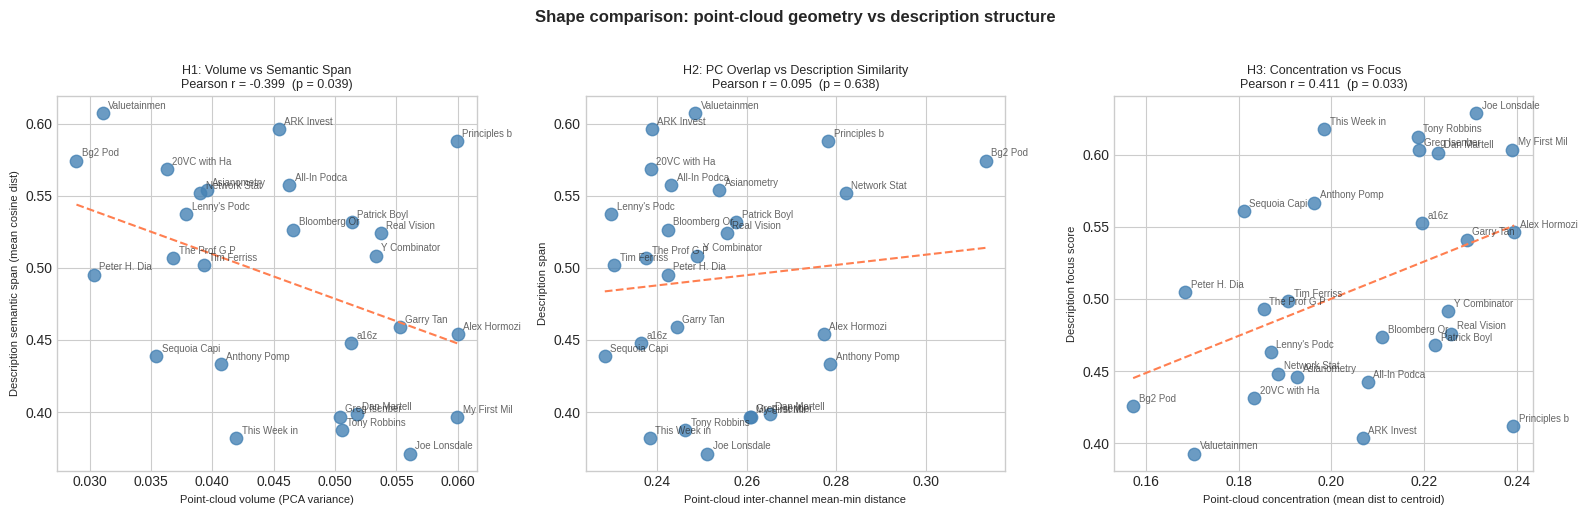

Saved → /content/drive/MyDrive/Research/shape_analysis/latest/shape_scatter.png


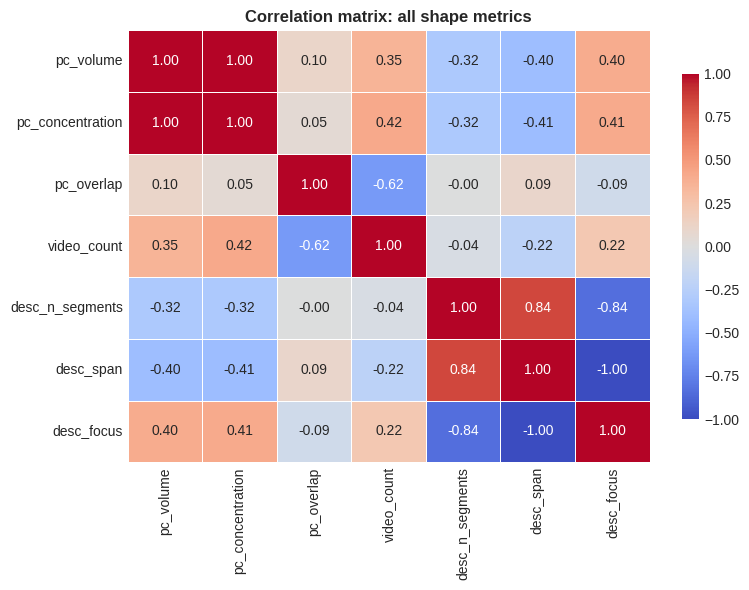

Saved → /content/drive/MyDrive/Research/shape_analysis/latest/shape_correlation_matrix.png


In [7]:
combined_df = shape_df.join(desc_shape_df)
print('Combined shape metrics:')
print(combined_df.round(4).to_string())

# ---- Three hypothesis scatter plots ----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

hypotheses = [
    ('pc_volume',        'desc_span',       'H1: Volume vs Semantic Span',
     'Point-cloud volume (PCA variance)', 'Description semantic span (mean cosine dist)'),
    ('pc_overlap',       'desc_span',       'H2: PC Overlap vs Description Similarity',
     'Point-cloud inter-channel mean-min distance', 'Description span'),
    ('pc_concentration', 'desc_focus',      'H3: Concentration vs Focus',
     'Point-cloud concentration (mean dist to centroid)', 'Description focus score'),
]

for ax, (x_col, y_col, title, xlabel, ylabel) in zip(axes, hypotheses):
    x = combined_df[x_col].values
    y = combined_df[y_col].values
    r, p = pearsonr(x, y)
    ax.scatter(x, y, s=80, color='steelblue', alpha=0.8)

    for ch_name, row in combined_df.iterrows():
        ax.annotate(str(ch_name)[:12], (row[x_col], row[y_col]),
                    fontsize=7, alpha=0.7, textcoords='offset points', xytext=(4, 3))

    # Regression line
    m, b = np.polyfit(x, y, 1)
    xs   = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, m * xs + b, color='coral', linewidth=1.5, linestyle='--')

    ax.set_title(f'{title}\nPearson r = {r:.3f}  (p = {p:.3f})', fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)

plt.suptitle('Shape comparison: point-cloud geometry vs description structure',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

shape_dir = RESEARCH_ROOT / 'shape_analysis' / 'latest'
shape_dir.mkdir(parents=True, exist_ok=True)
scatter_path = shape_dir / 'shape_scatter.png'
plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {scatter_path}')

# ---- Correlation heatmap of all shape metrics --------------------------------
corr = combined_df.select_dtypes(include=np.number).corr()
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax2, cbar_kws={'shrink': 0.8})
ax2.set_title('Correlation matrix: all shape metrics', fontweight='bold')
plt.tight_layout()
corr_path = shape_dir / 'shape_correlation_matrix.png'
plt.savefig(corr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {corr_path}')


## 7) Save artifacts

Write the merged shape metrics table and correlation matrix to Drive.


In [9]:
combined_df.round(6).to_csv(shape_dir / 'shape_metrics.csv')
corr.round(6).to_csv(shape_dir / 'shape_correlation.csv')

print(f'Saved shape_metrics.csv and shape_correlation.csv → {shape_dir}')

# Summary
print('\n--- Hypothesis summary ---')
for x_col, y_col, title, *_ in hypotheses:
    r, p = pearsonr(combined_df[x_col].values, combined_df[y_col].values)
    verdict = 'supported' if (r > 0.3 and p < 0.1) else ('refuted' if r < -0.3 else 'inconclusive')
    print(f'  {title}: r={r:.3f} p={p:.3f} → {verdict}')


Saved shape_metrics.csv and shape_correlation.csv → /content/drive/MyDrive/Research/shape_analysis/latest

--- Hypothesis summary ---
  H1: Volume vs Semantic Span: r=-0.399 p=0.039 → refuted
  H2: PC Overlap vs Description Similarity: r=0.095 p=0.638 → inconclusive
  H3: Concentration vs Focus: r=0.411 p=0.033 → supported
